In [1]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel("diabetes.xlsx")
print(df)
print(df.columns)
print(df.isnull().sum())
print(df.describe())

     AGE  SEX   BMI      BP   S1     S2    S3    S4      S5   S6    Y
0     59    2  32.1  101.00  157   93.2  38.0  4.00  4.8598   87  151
1     48    1  21.6   87.00  183  103.2  70.0  3.00  3.8918   69   75
2     72    2  30.5   93.00  156   93.6  41.0  4.00  4.6728   85  141
3     24    1  25.3   84.00  198  131.4  40.0  5.00  4.8903   89  206
4     50    1  23.0  101.00  192  125.4  52.0  4.00  4.2905   80  135
..   ...  ...   ...     ...  ...    ...   ...   ...     ...  ...  ...
437   60    2  28.2  112.00  185  113.8  42.0  4.00  4.9836   93  178
438   47    2  24.9   75.00  225  166.0  42.0  5.00  4.4427  102  104
439   60    2  24.9   99.67  162  106.6  43.0  3.77  4.1271   95  132
440   36    1  30.0   95.00  201  125.2  42.0  4.79  5.1299   85  220
441   36    1  19.6   71.00  250  133.2  97.0  3.00  4.5951   92   57

[442 rows x 11 columns]
Index(['AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'Y'], dtype='object')
AGE    0
SEX    0
BMI    0
BP     0
S1     

In [3]:
age = ctrl.Antecedent(np.arange(18, 100, 1), 'AGE')
bmi = ctrl.Antecedent(np.arange(15, 45, 1), 'BMI')
bp = ctrl.Antecedent(np.arange(60, 160, 1), 'BP')
y = ctrl.Consequent(np.arange(0, 350, 1), 'Y')

In [4]:
age['young'] = fuzz.trimf(age.universe, [18, 30, 40])
age['adult'] = fuzz.trimf(age.universe, [35, 45, 60])
age['senior'] = fuzz.trimf(age.universe, [55, 65, 80])
age['elderly'] = fuzz.trimf(age.universe, [75, 85, 100])

In [5]:
bmi['underweight'] = fuzz.trimf(bmi.universe, [15, 16, 18.5])
bmi['normal'] = fuzz.trimf(bmi.universe, [18.5, 21.7, 25])
bmi['overweight'] = fuzz.trimf(bmi.universe, [25, 27.5, 30])
bmi['obese_I'] = fuzz.trimf(bmi.universe, [30, 32.5, 35])
bmi['obese_II'] = fuzz.trimf(bmi.universe, [35, 37.5, 45])

In [6]:
bp['hypotension'] = fuzz.trimf(bp.universe, [60, 70, 80])
bp['normal'] = fuzz.trimf(bp.universe, [80, 90, 110])
bp['elevated'] = fuzz.trimf(bp.universe, [105, 115, 125])
bp['hypertension'] = fuzz.trimf(bp.universe, [120, 135, 160])

In [7]:
y['low_risk'] = fuzz.trimf(y.universe, [0, 50, 100])
y['moderate_risk'] = fuzz.trimf(y.universe, [80, 125, 175])
y['high_risk'] = fuzz.trimf(y.universe, [150, 200, 250])
y['critical_risk'] = fuzz.trimf(y.universe, [225, 300, 350])

In [8]:
rule1 = ctrl.Rule(age['young'] & bmi['normal'] & bp['normal'], y['low_risk'])
rule2 = ctrl.Rule(age['young'] & bmi['underweight'] & bp['hypotension'], y['low_risk'])
rule3 = ctrl.Rule(age['adult'] & bmi['overweight'] & bp['elevated'], y['moderate_risk'])
rule4 = ctrl.Rule(age['senior'] & bmi['normal'] & bp['elevated'], y['moderate_risk'])
rule5 = ctrl.Rule(age['senior'] & bmi['obese_I'] & bp['hypertension'], y['high_risk'])
rule6 = ctrl.Rule(age['elderly'] & bmi['overweight'] & bp['hypertension'], y['high_risk'])
rule7 = ctrl.Rule(age['elderly'] & bmi['obese_II'] & bp['hypertension'], y['critical_risk'])
rule8 = ctrl.Rule(bmi['obese_II'] & bp['hypertension'], y['critical_risk'])
rule9 = ctrl.Rule(age['young'] & bmi['obese_II'], y['high_risk'])
rule10 = ctrl.Rule(age['young'] & bp['hypertension'], y['high_risk'])
rule11 = ctrl.Rule(age['elderly'] & bp['hypertension'] & bmi['normal'], y['moderate_risk'])
rule12 = ctrl.Rule(age['adult'] & bmi['obese_I'] & bp['elevated'], y['high_risk'])
rule13 = ctrl.Rule(age['senior'] & bmi['normal'] & bp['normal'], y['low_risk'])
rule14 = ctrl.Rule(age['adult'] & bmi['overweight'] & bp['elevated'], y['moderate_risk'])
rule15 = ctrl.Rule(
    (age['young'] & bmi['normal'] & bp['elevated']) | (age['adult'] & bmi['normal'] & bp['hypertension']),
    y['moderate_risk'])
rule16 = ctrl.Rule(~(age['young'] | age['adult'] | age['senior'] | age['elderly']) | ~(
            bmi['underweight'] | bmi['normal'] | bmi['overweight'] | bmi['obese_I'] | bmi['obese_II']) | ~(
            bp['hypotension'] | bp['normal'] | bp['elevated'] | bp['hypertension']), y['moderate_risk'])

In [9]:
diabetes_ctrl = ctrl.ControlSystem(
    [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11, rule12, rule13, rule14, rule15,
     rule16])
diabetes_pred = ctrl.ControlSystemSimulation(diabetes_ctrl)

Predicted Y: 127.26


C:\Users\utente\AppData\Roaming\Python\Python312\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


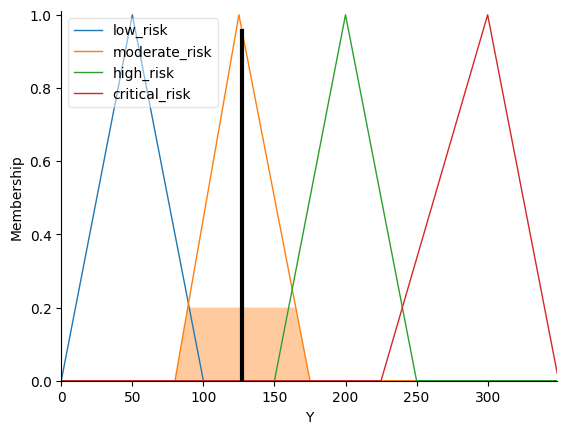

In [10]:
diabetes_pred.input['AGE'] = 30
diabetes_pred.input['BMI'] = 28
diabetes_pred.input['BP'] = 115
diabetes_pred.compute()

print(f"Predicted Y: {diabetes_pred.output['Y']:.2f}")

y.view(sim=diabetes_pred)
